In [88]:
import torch

In [89]:
checkpoint = torch.load('/home/jovyan/dnalm/runs/NATURE_GENA_RMT_10k_backbone_trainable_shuffle_starts_24_classes_fast_CRF_complete_random_start/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len1536_maxnsegm_10000_msz_10_bptt-1_lr1e-04_AdamW_constant_with_warmup_wd0.0_p10000_bs_it500000/run_1/model_best/pytorch_model.bin')

In [90]:
print(checkpoint['A'].shape)

torch.Size([24, 24])


/tmp/ipykernel_632894/2227421348.py:15: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  sns.heatmap(F.softmax(checkpoint['A'].cpu()).detach().numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)


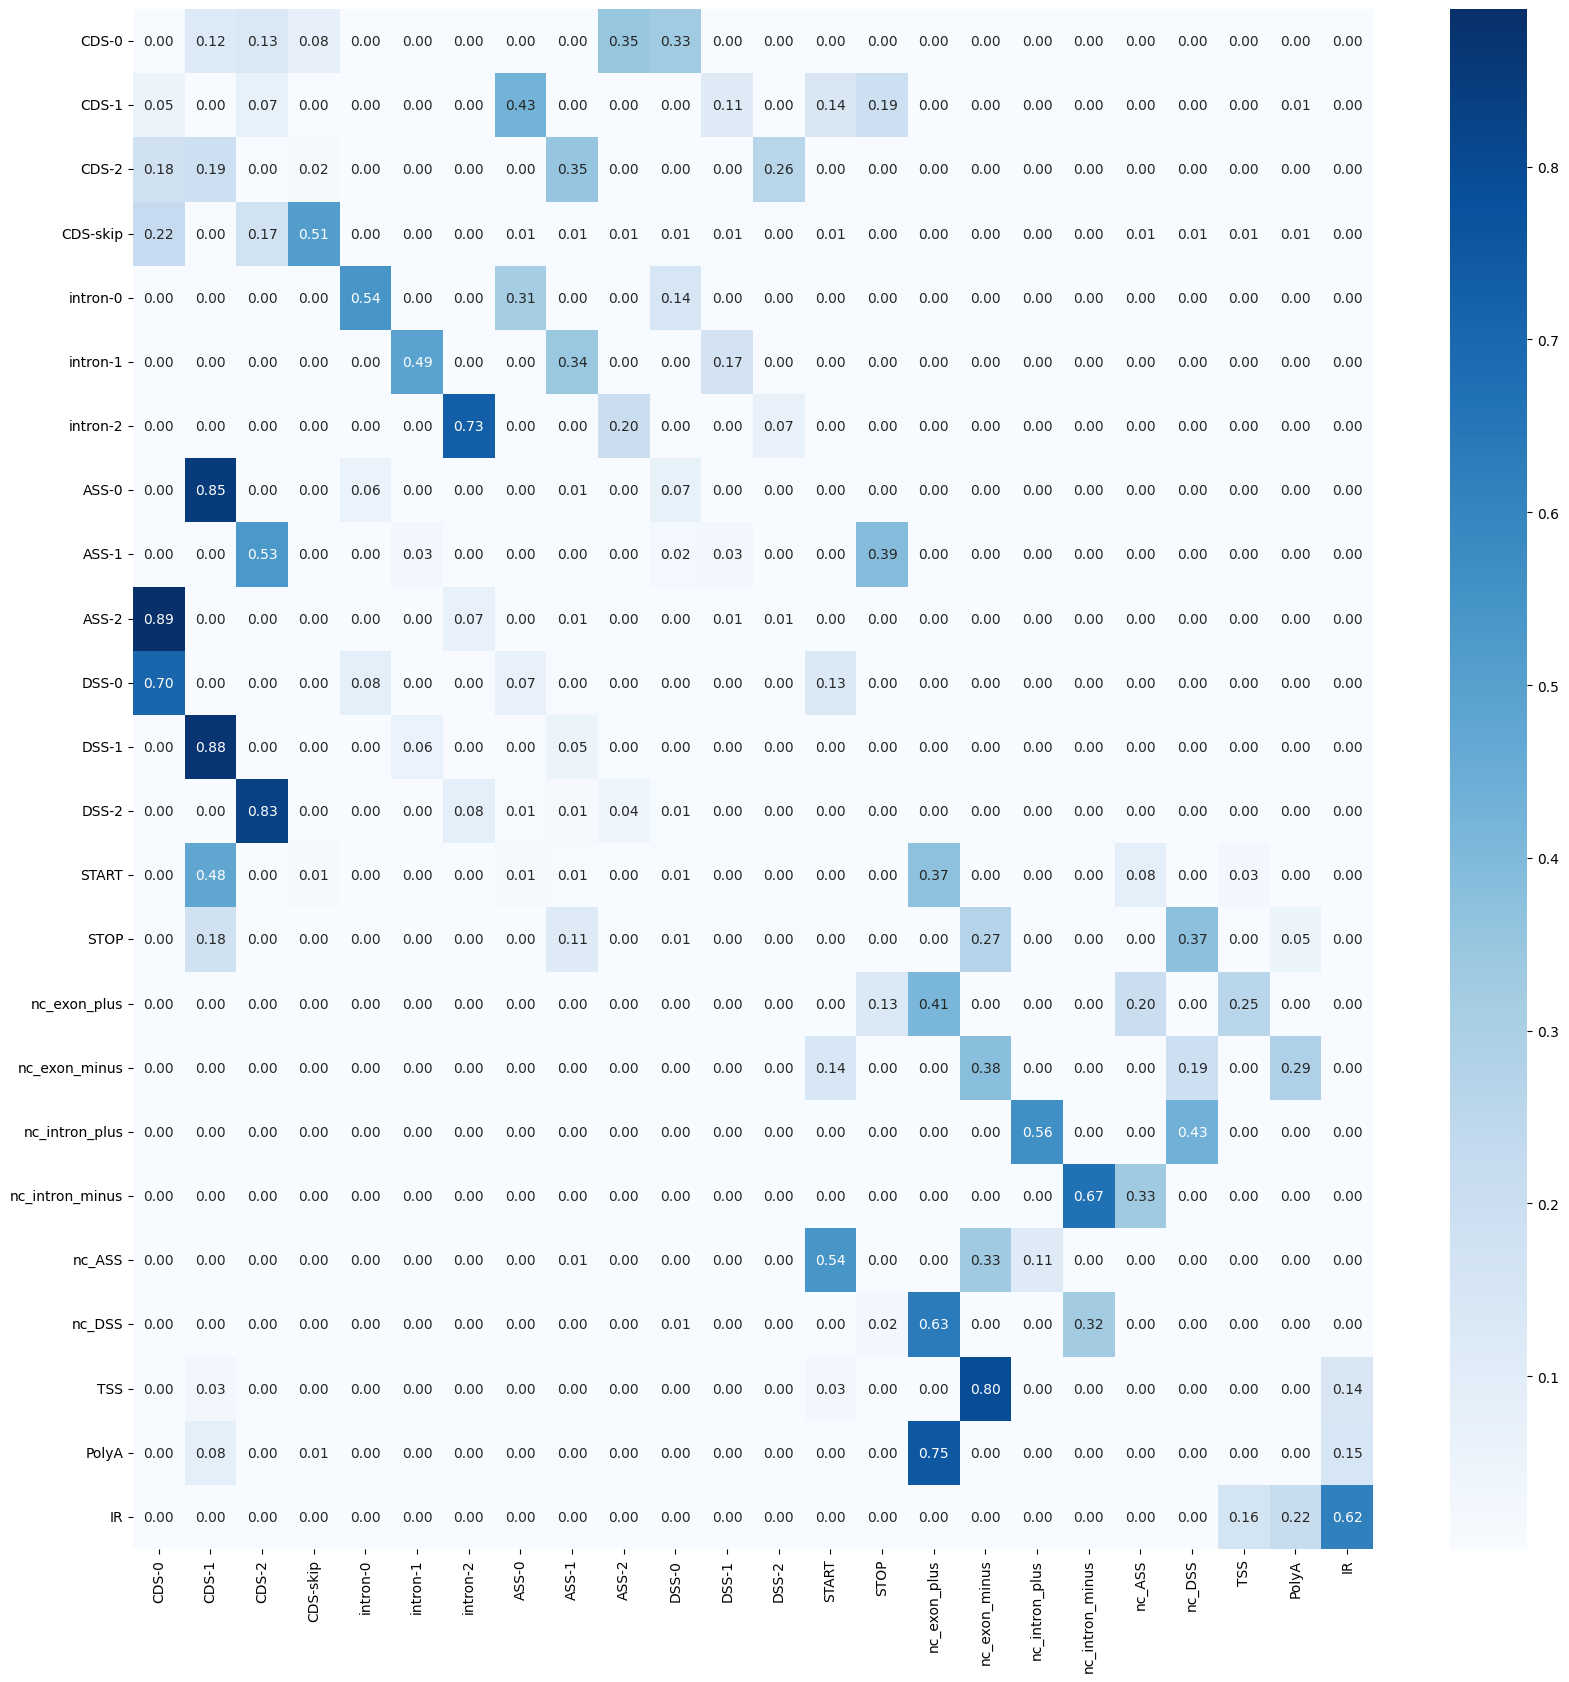

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F


# label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 3:'CDS-skip', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minus', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}
label_list = ['CDS-0', 'CDS-1', 'CDS-2', 'CDS-skip', 'intron-0', 'intron-1', 'intron-2',
 'ASS-0', 'ASS-1', 'ASS-2', 'DSS-0', 'DSS-1', 'DSS-2', 'START', 'STOP',
 'nc_exon_plus', 'nc_exon_minus', 'nc_intron_plus', 'nc_intron_minus',
 'nc_ASS', 'nc_DSS', 'TSS', 'PolyA', 'IR']


plt.figure(figsize=(20, 20))
# sns.heatmap(model.A.cpu().detach().numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=list(label_dict.values()), yticklabels=list(label_dict.values()))
sns.heatmap(F.softmax(checkpoint['A'].cpu()).detach().numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
plt.savefig('transitions.png')
plt.show()

# Test predictions

In [39]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import os
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F

os.chdir('/home/jovyan/dnalm/')
from transformers import AutoTokenizer, AutoConfig
tokenizer = AutoTokenizer.from_pretrained('./data/tokenizers/t2t_1000h_multi_32k/')
from src.gena_lm.modeling_bert import BertForLetterLevelTokenClassification
model_cfg = AutoConfig.from_pretrained('./data/configs/L12-H768-A12-V32k-preln-lastln.json') # here it soulbe config for backbone model, don't change it, you can change only path to it
model_cls = BertForLetterLevelTokenClassification
model = model_cls(config=model_cfg)

rmt_config = {
    'num_mem_tokens': 10,
    'max_n_segments': 100000,
    'input_size': 512,
    'bptt_depth': -1,
    'unet_sub_model_input_size': 8192,
    'sum_loss': True,
    'tokenizer': tokenizer
}

from src.gena_lm.modeling_rmt import RMTEncoderForLetterLevelTokenClassificationUNETsegmentedRepeaterCRFfast
rmt_cls = RMTEncoderForLetterLevelTokenClassificationUNETsegmentedRepeaterCRFfast
model = rmt_cls(model, **rmt_config)
# load pre-trained weights
ckpt = torch.load(str('/home/jovyan/dnalm/runs/NATURE_GENA_RMT_10k_backbone_trainable_shuffle_starts_24_classes_fast_CRF_complete_random_start/bert_large_512_lastln_t2t_1000G_bs256_lr_1e-04_fp16/model_1750000/rmt_seglen_512_len1536_maxnsegm_10000_msz_10_bptt-1_lr1e-04_AdamW_constant_with_warmup_wd0.0_p10000_bs_it500000/run_1/model_best/pytorch_model.bin'))
missing_k, unexpected_k = model.load_state_dict(ckpt, strict=False)
print(f'missing: {missing_k}') # if no missing tensors - that is correct, otherwise - no!
print(f'unexpected_k: {unexpected_k}') # if no missing tensors - that is correct, otherwise - no!
model_val = model.eval().to('cuda')
# model_val.half()

print('Loaded')

missing: []
unexpected_k: []
Loaded


In [40]:
def prepare_sequence(sequence, tokenizer):
    model_input = dict()
    input_features = tokenizer([sequence], return_tensors='np')
    
#    print(input_features['input_ids'].shape)
    
    model_input['input_ids'] = input_features['input_ids']
    model_input['token_type_ids'] = input_features['token_type_ids']
    model_input['attention_mask'] = input_features['attention_mask']
    model_input['labels'] = np.random.randint(0, 5, (1, model_input['input_ids'].shape[1], 5)) # change it in future
    # model_input['labels_ohe'] = torch.randint(0, 5, (model_input['input_ids'].shape[0], 5)) # change it in future
    pos_weight = torch.tensor([1.0]*5)
    bs, seq_len = model_input['input_ids'].shape
    model_input['pos_weight'] = pos_weight.repeat(bs, seq_len, 1)
    model_input['labels_mask'] = (input_features['input_ids'] > 5).astype(int)
    
    token_repeater_numbers = []
    meaningful_tokens_only = model_input['input_ids'][model_input['input_ids'] > 5]
    for t in meaningful_tokens_only:
        atcg_seq_token = tokenizer.convert_ids_to_tokens(int(t))
        token_repeater_numbers.append(len(atcg_seq_token))
    
    token_repeater = []
    for n, i in enumerate(token_repeater_numbers):
        # print(i)
        for j in range(i):
            token_repeater.append(n)
    
    letter_level_tokens = []
    for letter in sequence:
        letter_level_tokens.append(tokenizer.convert_tokens_to_ids(letter))
        
    # if len(letter_level_tokens) < max_length:
    #     letter_level_tokens += [-100] * (max_length - len(letter_level_tokens))
    #     token_repeater = token_repeater + [-100] * (max_length - len(token_repeater))

    model_input['letter_level_attention_mask'] = np.expand_dims(np.ones(len(letter_level_tokens)).astype(int), axis=0) # it's okay because we will truncate paddings with mask
    model_input['letter_level_token_types_ids'] = np.expand_dims(np.zeros(len(letter_level_tokens)).astype(int), axis=0)
    model_input['letter_level_tokens'] = np.expand_dims(np.array(letter_level_tokens), axis=0)
    model_input['letter_level_labels'] = np.array([[0] * len(letter_level_tokens)]) # np.random.randint(0, 5, (1, len(letter_level_tokens), 5)) # change it in future
    model_input['letter_level_labels_mask'] = model_input['letter_level_tokens'] != -100 #  model_input['letter_level_labels'] != -100
    model_input['embedding_repeater'] = np.expand_dims(np.array(token_repeater), axis=0)
    
    for k, v in model_input.items():
        model_input[k] = torch.tensor(v).to('cuda')
        # print(k, v.shape)
    
    return model_input

In [41]:
file_path = './downstream_tasks/annotation/notebook_tests/NC_060944.1_limit_10Mb_transcript_list.txt'

selected_transcripts = []
with open(file_path, 'r') as file:
    for line in file:
        cleaned_line = line.strip()  # Removes leading/trailing whitespace including \n
        selected_transcripts.append(cleaned_line)

In [42]:
dataset_file[f'transcript_{transcript_idx}'].attrs.keys()

<KeysViewHDF5 ['ID', 'Parent', 'genome', 'seq', 'strand', 'type']>

In [43]:
dataset_file[f'transcript_{transcript_idx}'].attrs['ID']

'rna-XR_007089328.1'

In [70]:
import pickle

file_path = './downstream_tasks/annotation/notebook_tests/transcripts_test.pickle'

with open(file_path, 'rb') as file:
    transcripts_dict = pickle.load(file)

In [71]:
len(transcripts_dict.keys())

123

In [74]:
import h5py
from tqdm import tqdm
import math
# dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoding_human_mane_transcripts/gena_decoder_human_val_intergenic_2k_mane_transcripts_only.h5', "r")

exist_in_dataset = []

all_preds, all_targets = [], []
for transcript in tqdm(transcripts_dict.values()):

    num_segments = math.ceil(len(transcript) / 10_000)
    # print(num_segments)
    for i in range(num_segments):
        dataset_seq_atcg = transcript[i*10_000:(i+1)*10_000]
        # dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[i*10_000:(i+1)*10_000]

        # if i == 0:
        #     print(len(exist_in_dataset))
        #     assert np.all(dataset_labels[:2000] == 23)
    
        with torch.no_grad():
            # fully_prepared_sequence = prepare_sequence(dataset_seq_atcg, tokenizer)
            gene_pred = model(**prepare_sequence(dataset_seq_atcg, tokenizer))
        gene_pred_processed = gene_pred['logits'].detach().cpu()
    
        all_preds.append(gene_pred_processed)
        # all_targets.append(torch.tensor(dataset_labels))

  0%|          | 0/123 [00:00<?, ?it/s]/tmp/ipykernel_632894/1048820093.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input[k] = torch.tensor(v).to('cuda')
100%|██████████| 123/123 [05:48<00:00,  2.83s/it]


In [79]:
import h5py
from tqdm import tqdm
import math
dataset_file = h5py.File('/home/jovyan/shares/SR003.nfs2/decoding_human_mane_transcripts/gena_decoder_human_val_intergenic_2k_mane_transcripts_only.h5', "r")

exist_in_dataset = []

all_preds, all_targets = [], []
# for transcript_idx in tqdm(range(len(dataset_file))):
for transcript_idx in tqdm(range(1000)):

    # print(np.array(dataset_file[f'transcript_{transcript_idx}']["coordinates"]))
    # if dataset_file[f'transcript_{transcript_idx}'].attrs['ID'] in selected_transcripts:
    #     exist_in_dataset.append(dataset_file[f'transcript_{transcript_idx}'].attrs['ID'])
    # print(len(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])))
    num_segments = math.ceil(len(np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])) / 10_000)
    # print(num_segments)
    for i in range(num_segments):
        dataset_seq_atcg = tokenizer.decode(np.array(dataset_file[f'transcript_{transcript_idx}']["token_atcg"])[i*10_000:(i+1)*10_000])
        dataset_labels = np.array(dataset_file[f'transcript_{transcript_idx}']["labels"])[i*10_000:(i+1)*10_000]

        # if i == 0:
        #     print(len(exist_in_dataset))
        #     assert np.all(dataset_labels[:2000] == 23)
    
        with torch.no_grad():
            # fully_prepared_sequence = prepare_sequence(dataset_seq_atcg, tokenizer)
            gene_pred = model(**prepare_sequence(dataset_seq_atcg, tokenizer))
        gene_pred_processed = gene_pred['logits'].detach().cpu()
    
        all_preds.append(gene_pred_processed)
        all_targets.append(torch.tensor(dataset_labels))

  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_632894/1048820093.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input[k] = torch.tensor(v).to('cuda')
100%|██████████| 1000/1000 [1:04:51<00:00,  3.89s/it]


In [45]:
import pickle

# Replace 'your_file.pkl' with your actual pickle file path
file_path = './downstream_tasks/annotation/notebook_tests/10k.pickle'

with open(file_path, 'rb') as file:
    pickle_file = pickle.load(file)

In [62]:
len(exist_in_dataset)

123

In [31]:
np.all(pickle_file['embedding_repeater'].squeeze().cpu().numpy() == fully_prepared_sequence['embedding_repeater'].squeeze().cpu().numpy())

ValueError: operands could not be broadcast together with shapes (10000,) (5070,) 

In [190]:
np.all(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze() == fully_prepared_sequence['input_ids'].squeeze().cpu().numpy())

True

In [188]:
np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze()[:10]

array([    1,   923,   216,  9523,   598,   205,   112,  1616,   294,
       13820])

In [189]:
fully_prepared_sequence['input_ids'].squeeze()[:10]

tensor([    1,   923,   216,  9523,   598,   205,   112,  1616,   294, 13820],
       device='cuda:0')

In [187]:
np.sum(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze() == fully_prepared_sequence['input_ids'].squeeze())

0

In [185]:
len(fully_prepared_sequence['input_ids'].squeeze())

1508

In [186]:
len(np.load('./downstream_tasks/annotation/notebook_tests/bpe_10k.npy').squeeze())

1508

In [168]:
output_path = './downstream_tasks/annotation/notebook_tests/selected_transcripts.txt'

with open(output_path, 'w') as file:
    for line in exist_in_dataset:
        file.write(line + '\n')  # Add newline character back for each line

In [61]:
len(selected_transcripts)

170

In [82]:
torch.cat(all_preds, dim=-1).shape

torch.Size([1, 44361873])

In [81]:
torch.cat(all_targets, dim=-1).shape

torch.Size([44361873])

In [56]:
def find_segments_ones(array):
    ones_idx = np.where(array == 1)[0]
    if len(ones_idx) == 0:
        return []

    split_idx = np.where(np.diff(ones_idx) > 1)[0] + 1

    split_ones_idx = np.split(ones_idx, split_idx)
    segments = [(segment[0], segment[-1] + 1) for segment in split_ones_idx]

    return segments

def exon_level(y_labels, p_labels, metrics):     
    """
    Update metrics with chosen threshold
    """
    y_labels_segments = find_segments_ones(np.where(y_labels >= 0.5, 1, 0))    
    p_labels_segments = find_segments_ones(np.where(p_labels >= 0.5, 1, 0))


    y_exons_set = set(sorted(y_labels_segments))
    p_exons_set = set(sorted(p_labels_segments))

    assert metrics[f'TP'] == 0
    assert metrics[f'FP'] == 0
    assert metrics[f'FN'] == 0
    
    metrics[f'TP'] += len(y_exons_set & p_exons_set)
    metrics[f'FP'] += len(p_exons_set - y_exons_set)
    metrics[f'FN'] += len(y_exons_set - p_exons_set)

In [83]:
all_pred = torch.cat(all_preds, dim=-1).squeeze()
all_y = torch.cat(all_targets, dim=-1)

In [52]:
first_pred = np.load('./downstream_tasks/annotation/notebook_tests/first_preds.npy')
decreaser = 3
np.all(all_pred[:].numpy() == first_pred[:])

True

In [37]:
all_pred.sum()

tensor(303176)

In [38]:
np.sum(~(all_pred.numpy() == first_pred))

142

In [59]:
all_pred[10_000-7:10_000+7]

tensor([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23])

In [60]:
first_pred[10_000-7:10_000+7]

array([23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23])

In [76]:
torch.sum(all_pred == 21)

tensor(481)

In [87]:
list(label_dict.values())

['CDS-0',
 'CDS-1',
 'CDS-2',
 'CDS-skip',
 'intron-0',
 'intron-1',
 'intron-2',
 'ASS-0',
 'ASS-1',
 'ASS-2',
 'DSS-0',
 'DSS-1',
 'DSS-2',
 'START',
 'STOP',
 'nc_exon_plus',
 'nc_exon_minus',
 'nc_intron_plus',
 'nc_intron_minus',
 'nc_ASS',
 'nc_DSS',
 'TSS',
 'PolyA',
 'IR']

In [84]:
metrics = {}

assert -100 not in all_pred
assert -100 not in all_y

label_dict = {0: 'CDS-0', 1:'CDS-1', 2:'CDS-2', 3:'CDS-skip', 4:'intron-0', 5:'intron-1', 6:'intron-2', 7:'ASS-0', 8:'ASS-1', 9:'ASS-2', 10:'DSS-0', 11:'DSS-1', 12:'DSS-2', 13:'START', 14:'STOP', 15:'nc_exon_plus', 16:'nc_exon_minus', 17:'nc_intron_plus', 18:'nc_intron_minus', 19:'nc_ASS', 20:'nc_DSS', 21:'TSS' , 22:'PolyA', 23:'IR'}

# metrics['pr_auc_mean'] = 0
metrics['f1_mean'] = 0
# metrics['val_counter'] = val_counter
# val_counter += 1
for label in range(24):
    # print(y_rmt)
    y_label = (all_y == label).type(torch.int32)
    p_label = (all_pred == label).type(torch.int32)

    # print(y_label, p_label)
    # assert False
    
    # if not np.isnan(p_label).any():
    #     pr_auc = average_precision_score(y_label, p_label, pos_label=1)
    # else:
    #     pr_auc = np.nan
    # # to be compatible with sklearn 1.1+
    # metrics[f'pr_auc_{label_dict[label]}'] = pr_auc if not np.isnan(pr_auc) else 0.0

    # metrics['pr_auc_mean'] += metrics[f'pr_auc_{label_dict[label]}']

    exon_level_data = {}

    exon_level_data[f'TP'] = 0
    exon_level_data[f'FP'] = 0
    exon_level_data[f'FN'] = 0

    exon_level(y_label, p_label, exon_level_data)

    if exon_level_data[f'TP'] == 0 and exon_level_data[f'FN'] == 0:
        recall = 0
    else:
        recall = exon_level_data[f'TP'] / (exon_level_data[f'TP'] + exon_level_data[f'FN'])
        
    if exon_level_data[f'TP'] == 0 and exon_level_data[f'FP'] == 0:
        precision = 0
    else:
        precision = exon_level_data[f'TP'] / (exon_level_data[f'TP'] + exon_level_data[f'FP'])    

    if precision == 0 and recall == 0:
        f1 = 0
    else:
        f1 = 2 * recall * precision / (recall + precision) 

    metrics[f'f1_{label_dict[label]}_level'] = f1
    metrics['f1_mean'] += metrics[f'f1_{label_dict[label]}_level']
    metrics[f'precision_{label_dict[label]}_level'] = precision
    metrics[f'recall_{label_dict[label]}_level'] = recall

# metrics['pr_auc_mean'] /= 24
metrics['f1_mean'] /= 24

In [85]:
metrics

{'f1_mean': 0.16733183982928623,
 'f1_CDS-0_level': 0.40838492581460234,
 'precision_CDS-0_level': 0.7482748406490329,
 'recall_CDS-0_level': 0.28082527369820937,
 'f1_CDS-1_level': 0.4089436840455542,
 'precision_CDS-1_level': 0.7476232576923497,
 'recall_CDS-1_level': 0.28144620492422995,
 'f1_CDS-2_level': 0.40910954497164487,
 'precision_CDS-2_level': 0.748811375736728,
 'recall_CDS-2_level': 0.28143515335175173,
 'f1_CDS-skip_level': 0,
 'precision_CDS-skip_level': 0,
 'recall_CDS-skip_level': 0,
 'f1_intron-0_level': 0.1559707554833469,
 'precision_intron-0_level': 0.4897959183673469,
 'recall_intron-0_level': 0.0927536231884058,
 'f1_intron-1_level': 0.1339001062699256,
 'precision_intron-1_level': 0.5121951219512195,
 'recall_intron-1_level': 0.07701711491442542,
 'f1_intron-2_level': 0.16249361267245782,
 'precision_intron-2_level': 0.3859223300970874,
 'recall_intron-2_level': 0.1029126213592233,
 'f1_ASS-0_level': 0.20728744939271257,
 'precision_ASS-0_level': 0.630541871921